In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(
    "portfolio_mexico_filled.csv"
)

Saving portfolio_mexico_filled.csv to portfolio_mexico_filled.csv


In [4]:
df["policy_start_date"] = pd.to_datetime(
    df["policy_start_date"],
    dayfirst=True,
    errors="coerce"
)

df["policy_end_date"] = pd.to_datetime(
    df["policy_end_date"],
    dayfirst=True,
    errors="coerce"
)

In [5]:
df["year"] = (
    df["policy_start_date"]
    .dt.year
)

df["month"] = (
    df["policy_start_date"]
    .dt.month
)

df["year_month"] = (
    df["policy_start_date"]
    .dt.to_period("M")
)

In [6]:
annual_premium = (
    df
    .groupby("year", as_index=False)
    .agg(
        premium=("premium", "sum"),
        policies=("policy_id", "nunique"),
        clients=("ClientId", "nunique")
    )
)

annual_premium

,year,premium,policies,clients
0,2021,"5,708,419,255.28",12604,4821
1,2022,"5,880,996,179.68",12608,4791
2,2023,"5,940,216,680.53",12573,4801
3,2024,"5,935,730,657.61",12656,4822


In [7]:
annual_premium["premium_growth_yoy"] = (
    annual_premium["premium"]
    .pct_change()
)

annual_premium

,year,premium,policies,clients,premium_growth_yoy
0,2021,"5,708,419,255.28",12604,4821,NaN
1,2022,"5,880,996,179.68",12608,4791,0.03
2,2023,"5,940,216,680.53",12573,4801,0.01
3,2024,"5,935,730,657.61",12656,4822,-0.00


In [14]:
def calculate_premium_growth(data, group_cols):

    summary = (
        data
        .groupby(group_cols + ["year"], as_index=False)
        .agg(
            premium=("premium", "sum"),
            policies=("policy_id", "nunique"),
            clients=("ClientId", "nunique")
        )
        .sort_values(group_cols + ["year"])
    )

    summary["premium_previous_year"] = (
        summary
        .groupby(group_cols)["premium"]
        .shift(1)
    )

    summary["premium_change"] = (
        summary["premium"]
        - summary["premium_previous_year"]
    )

    summary["premium_growth_yoy"] = (
        summary["premium"]
        .div(summary["premium_previous_year"])
        .sub(1)
    )

    return summary

##By industry

In [15]:
industry_year = calculate_premium_growth(
    df,
    ["industry_final"]
)

industry_year.head(30)

,industry_final,year,premium,policies,clients,premium_previous_year,premium_change,premium_growth_yoy
0,Agricultura,2021,"212,776,780.00",380,177,NaN,NaN,NaN
1,Agricultura,2022,"220,903,266.94",428,184,"212,776,780.00","8,126,486.94",0.04
2,Agricultura,2023,"208,201,188.54",421,198,"220,903,266.94","-12,702,078.40",-0.06
3,Agricultura,2024,"175,638,937.86",442,190,"208,201,188.54","-32,562,250.68",-0.16
4,Alimentos y Bebidas,2021,"331,818,041.92",753,362,NaN,NaN,NaN
5,Alimentos y Bebidas,2022,"396,195,220.32",803,357,"331,818,041.92","64,377,178.40",0.19
6,Alimentos y Bebidas,2023,"397,437,222.49",835,365,"396,195,220.32","1,242,002.17",0.00
7,Alimentos y Bebidas,2024,"383,619,319.83",763,367,"397,437,222.49","-13,817,902.66",-0.03
8,Comercio al por Mayor,2021,"422,354,234.21",1002,463,NaN,NaN,NaN
9,Comercio al por Mayor,2022,"473,506,786.80",1002,482,"422,354,234.21","51,152,552.59",0.12


In [19]:
industry_2024 = (
    calculate_premium_growth(
        df,
        ["industry_final"]
    )
    .query("year == 2024")
    .sort_values(
        "premium",
        ascending=False
    )
)

industry_2024[
    [
        "industry_final",
        "premium",
        "premium_change",
        "premium_growth_yoy",
        "policies",
        "clients"
    ]
]

,industry_final,premium,premium_change,premium_growth_yoy,policies,clients
19,Construcción,"1,665,065,518.70","142,763,765.15",0.09,3765,551
35,Manufactura,"690,810,014.72","-75,322,000.45",-0.10,1366,654
11,Comercio al por Mayor,"450,678,316.33","-32,800,961.69",-0.07,1005,478
59,Transporte y Logística,"420,053,142.88","-45,505,965.04",-0.10,822,384
15,Comercio al por Menor,"405,243,219.92","17,752,465.82",0.05,867,397
7,Alimentos y Bebidas,"383,619,319.83","-13,817,902.66",-0.03,763,367
43,Salud,"340,564,880.03","64,986,536.39",0.24,554,250
23,Educación,"232,379,793.63","-23,901,567.88",-0.09,541,228
31,Inmobiliaria,"219,837,895.65","-2,801,537.47",-0.01,487,222
27,Hotelería y Turismo,"215,054,040.17","-30,303,117.78",-0.12,433,199


##By state

In [17]:
state_year = calculate_premium_growth(
    df,
    ["state"]
)

state_2024 = (
    state_year[
        state_year["year"] == 2024
    ]
    .sort_values(
        "premium",
        ascending=False
    )
)

state_2024[
    [
        "state",
        "premium",
        "premium_growth_yoy",
        "policies",
        "clients"
    ]
]

,state,premium,premium_growth_yoy,policies,clients
79,Tamaulipas,"1,297,219,095.85",0.11,2847,148
19,Ciudad de México,"830,182,384.02",-0.07,1840,884
47,Nuevo León,"667,176,408.16",0.09,1385,653
39,Jalisco,"475,815,447.12",-0.05,967,456
27,Estado de México,"383,626,488.86",-0.07,766,369
31,Guanajuato,"283,957,391.44",0.25,556,273
83,Veracruz,"233,387,847.61",-0.19,482,225
59,Puebla,"232,799,772.06",-0.04,439,223
23,Coahuila,"201,859,491.70",-0.08,470,212
63,Querétaro,"171,279,787.88",-0.08,341,167


##Industry × state

In [18]:
industry_state_year = calculate_premium_growth(
    df,
    [
        "industry_final",
        "state"
    ]
)

industry_state_year.head()

,industry_final,state,year,premium,policies,clients,premium_previous_year,premium_change,premium_growth_yoy
0,Agricultura,Aguascalientes,2021,"3,169,280.99",10,5,NaN,NaN,NaN
1,Agricultura,Aguascalientes,2022,"5,056,034.89",15,4,"3,169,280.99","1,886,753.90",0.60
2,Agricultura,Aguascalientes,2023,"4,696,191.69",15,5,"5,056,034.89","-359,843.20",-0.07
3,Agricultura,Aguascalientes,2024,"3,404,955.58",17,4,"4,696,191.69","-1,291,236.11",-0.27
4,Agricultura,Baja California,2021,"3,613,431.05",15,6,NaN,NaN,NaN


In [21]:
growth_contributors = (
    industry_2024[
        industry_2024["premium_change"].notna()
    ]
    .sort_values(
        "premium_change",
        ascending=False
    )
)

growth_contributors[
    [
        "industry_final",
        "premium_change",
        "premium_growth_yoy"
    ]
]

,industry_final,premium_change,premium_growth_yoy
19,Construcción,"142,763,765.15",0.09
43,Salud,"64,986,536.39",0.24
15,Comercio al por Menor,"17,752,465.82",0.05
39,Minería,"14,753,446.61",0.10
63,Unknown,"12,644,154.83",0.08
51,Servicios Profesionales,"6,875,254.10",0.04
55,Tecnología,"-1,718,119.01",-0.02
31,Inmobiliaria,"-2,801,537.47",-0.01
47,Servicios Financieros,"-5,528,223.16",-0.04
7,Alimentos y Bebidas,"-13,817,902.66",-0.03


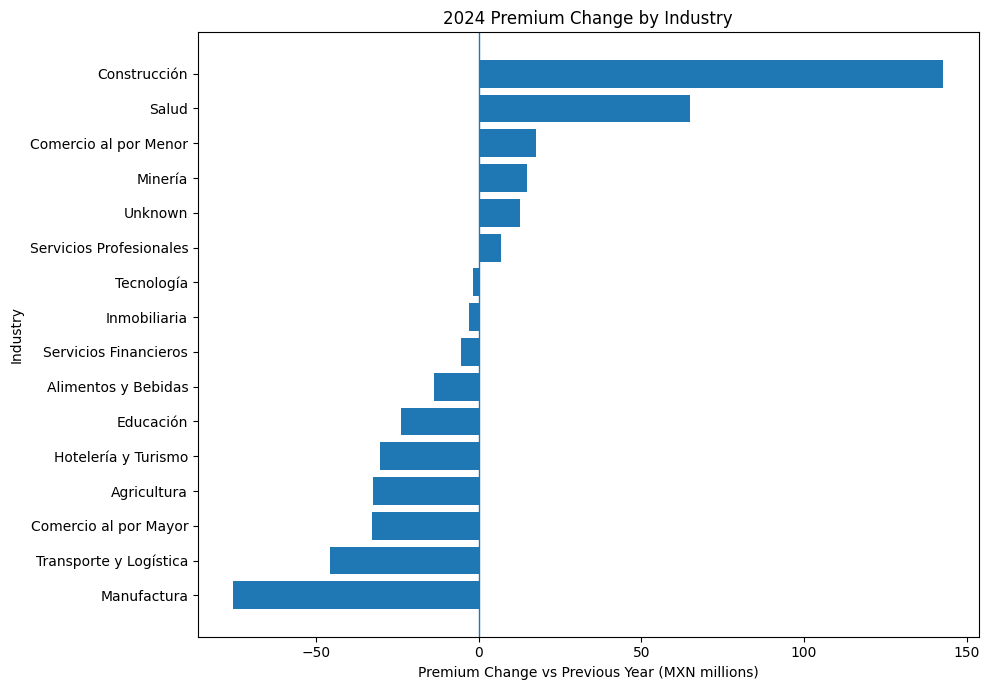

In [22]:
import matplotlib.pyplot as plt

plot_data = (
    growth_contributors
    .sort_values("premium_change")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["industry_final"],
    plot_data["premium_change"] / 1_000_000
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Premium Change vs Previous Year (MXN millions)")
plt.ylabel("Industry")
plt.title("2024 Premium Change by Industry")

plt.tight_layout()
plt.show()

##Premium x policy

In [23]:
industry_year = calculate_premium_growth(
    df,
    ["industry_final"]
)

industry_year["premium_per_policy"] = (
    industry_year["premium"]
    / industry_year["policies"]
)

In [24]:
industry_year["premium_per_policy_growth_yoy"] = (
    industry_year
    .groupby("industry_final")[
        "premium_per_policy"
    ]
    .pct_change()
)

In [25]:
industry_diagnostics_2024 = (
    industry_year[
        industry_year["year"] == 2024
    ][
        [
            "industry_final",
            "premium",
            "premium_growth_yoy",
            "premium_change",
            "policies",
            "premium_per_policy",
            "premium_per_policy_growth_yoy"
        ]
    ]
    .sort_values(
        "premium",
        ascending=False
    )
)

industry_diagnostics_2024

,industry_final,premium,premium_growth_yoy,premium_change,policies,premium_per_policy,premium_per_policy_growth_yoy
19,Construcción,"1,665,065,518.70",0.09,"142,763,765.15",3765,"442,248.48",0.04
35,Manufactura,"690,810,014.72",-0.10,"-75,322,000.45",1366,"505,717.43",-0.09
11,Comercio al por Mayor,"450,678,316.33",-0.07,"-32,800,961.69",1005,"448,436.14",-0.10
59,Transporte y Logística,"420,053,142.88",-0.10,"-45,505,965.04",822,"511,013.56",-0.07
15,Comercio al por Menor,"405,243,219.92",0.05,"17,752,465.82",867,"467,408.56",0.03
7,Alimentos y Bebidas,"383,619,319.83",-0.03,"-13,817,902.66",763,"502,777.61",0.06
43,Salud,"340,564,880.03",0.24,"64,986,536.39",554,"614,738.05",0.30
23,Educación,"232,379,793.63",-0.09,"-23,901,567.88",541,"429,537.51",-0.09
31,Inmobiliaria,"219,837,895.65",-0.01,"-2,801,537.47",487,"451,412.52",-0.02
27,Hotelería y Turismo,"215,054,040.17",-0.12,"-30,303,117.78",433,"496,660.60",-0.11


##Policy growth

In [26]:
def calculate_premium_growth(data, group_cols):

    summary = (
        data
        .groupby(group_cols + ["year"], as_index=False)
        .agg(
            premium=("premium", "sum"),
            policies=("policy_id", "nunique"),
            clients=("ClientId", "nunique")
        )
        .sort_values(group_cols + ["year"])
    )

    summary["premium_previous_year"] = (
        summary
        .groupby(group_cols)["premium"]
        .shift(1)
    )

    summary["premium_change"] = (
        summary["premium"]
        - summary["premium_previous_year"]
    )

    summary["premium_growth_yoy"] = (
        summary["premium"]
        .div(summary["premium_previous_year"])
        .sub(1)
    )

    summary["policy_growth_yoy"] = (
        summary
        .groupby(group_cols)["policies"]
        .pct_change()
    )

    summary["premium_per_policy"] = (
        summary["premium"]
        / summary["policies"]
    )

    summary["premium_per_policy_growth_yoy"] = (
        summary
        .groupby(group_cols)["premium_per_policy"]
        .pct_change()
    )

    return summary

In [27]:
industry_year = calculate_premium_growth(
    df,
    ["industry_final"]
)

industry_2024 = (
    industry_year[
        industry_year["year"] == 2024
    ]
    .sort_values(
        "premium",
        ascending=False
    )
)

In [28]:
industry_2024[
    [
        "industry_final",
        "premium_growth_yoy",
        "policy_growth_yoy",
        "premium_per_policy_growth_yoy",
        "premium_change"
    ]
]

,industry_final,premium_growth_yoy,policy_growth_yoy,premium_per_policy_growth_yoy,premium_change
19,Construcción,0.09,0.05,0.04,"142,763,765.15"
35,Manufactura,-0.10,-0.01,-0.09,"-75,322,000.45"
11,Comercio al por Mayor,-0.07,0.04,-0.10,"-32,800,961.69"
59,Transporte y Logística,-0.10,-0.03,-0.07,"-45,505,965.04"
15,Comercio al por Menor,0.05,0.02,0.03,"17,752,465.82"
7,Alimentos y Bebidas,-0.03,-0.09,0.06,"-13,817,902.66"
43,Salud,0.24,-0.05,0.30,"64,986,536.39"
23,Educación,-0.09,-0.00,-0.09,"-23,901,567.88"
31,Inmobiliaria,-0.01,0.01,-0.02,"-2,801,537.47"
27,Hotelería y Turismo,-0.12,-0.02,-0.11,"-30,303,117.78"


## Business Interpretation

At the portfolio level, written premium remained relatively stable in 2024, with only a slight decrease compared with 2023. However, looking at the portfolio by industry shows that there were important differences behind this overall result.

Construction was the main positive contributor to premium change, with growth coming from both a higher number of policies and an increase in premium per policy.

Health also recorded strong premium growth, even though the number of policies decreased. In this case, the growth was mainly explained by a significant increase in premium per policy.

On the other hand, Manufacturing showed one of the largest declines in premium. The decrease was driven mainly by a lower premium per policy, while policy volume remained relatively stable.

Overall, these results show that Premium Growth alone does not provide the full picture. It is important to analyze it together with absolute Premium Change, policy volume, and premium per policy to better understand what is driving the portfolio results.